## Model Evaluation

In [4]:
import random
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

In [11]:
def evaluate_model(model, *test_set):
    X_test, y_test = test_set

    test_result = model.evaluate(X_test, y_test)
    return test_result

In [18]:
def visualise_predictions(model, seed_value, *test_set):
    X_test, y_test = test_set

    random.seed(seed_value)

    rows = 4
    cols = 5

    num_data = rows * cols
    shuffledIndices = random.sample(range(y_test.shape[0]), num_data)

    X_sampled = tf.gather(X_test, shuffledIndices)
    y_sampled = tf.gather(y_test, shuffledIndices)

    # Generate predictions on sampled test set
    y_predictions = model.predict(X_sampled)

    numMatches = 0

    plt.figure(figsize=(18, 12))
    for i in range(num_data):
        plt.subplot(rows, cols, i + 1)
        pred = np.argmax(y_predictions[i])
        truth = np.argmax(y_sampled[i])

        title = f"Truth: {truth} Pred: {pred}"
        title_obj = plt.title(title, fontdict={"fontsize": 16})

        if pred == truth:
            numMatches += 1
            plt.setp(title_obj, color="green")
        else:
            plt.setp(title_obj, color="red")

        plt.axis("off")
        plt.imshow(X_sampled[i].numpy().squeeze(), cmap="gray")

    plt.subplots_adjust(wspace=0.2, hspace=0.2)
    plt.show(block=False)
    print(numMatches)

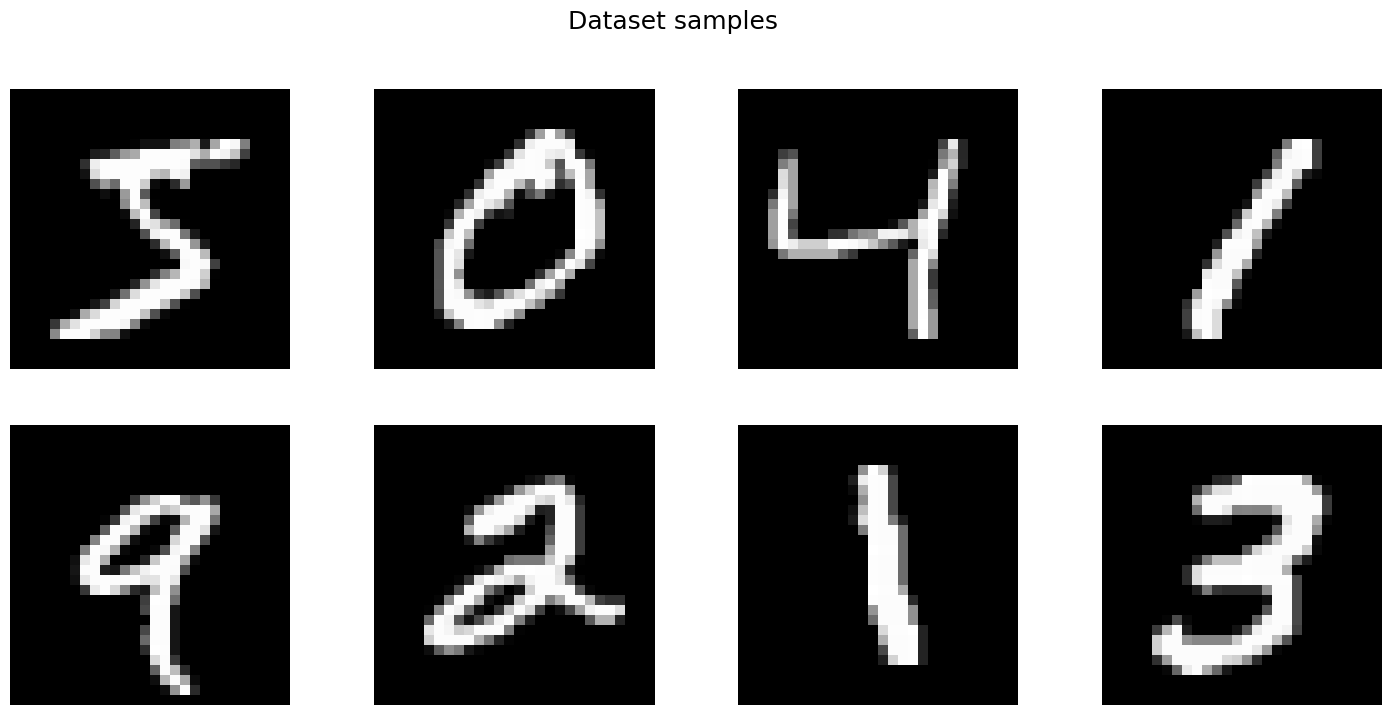



Num of training examples: 54000
Num of validation examples: 6000
Num of test examples: 10000
Image data shape: (32, 32, 1)

Data Split:

Shape X_train: (54000, 32, 32, 1) y_train: (54000, 10)
Shape X_valid: (6000, 32, 32, 1) y_valid: (6000, 10)
Shape X_test: (10000, 32, 32, 1) y_test: (10000, 10)

Ground truth labels have been one-hot encoded: 

[[0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 1. 0. 0. 0.]
 [1. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 1.]]


Model: "LeNet5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 10, 10, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)




Epoch 1/21
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8427 - loss: 0.5221 - val_accuracy: 0.9238 - val_loss: 0.2419
Epoch 2/21
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9567 - loss: 0.1408 - val_accuracy: 0.9635 - val_loss: 0.1182
Epoch 3/21
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9690 - loss: 0.0985 - val_accuracy: 0.9737 - val_loss: 0.0826
Epoch 4/21
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9753 - loss: 0.0791 - val_accuracy: 0.9745 - val_loss: 0.0829
Epoch 5/21
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9788 - loss: 0.0690 - val_accuracy: 0.9783 - val_loss: 0.0665
Epoch 6/21
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9811 - loss: 0.0603 - val_accuracy: 0.9805 - val_loss: 0.0639
Epoch 7/21
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9833 - loss: 0.0536 - val_accuracy: 0.9835 - val_loss: 0.0539
Epoch 8/21
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9843 - loss: 0.0491

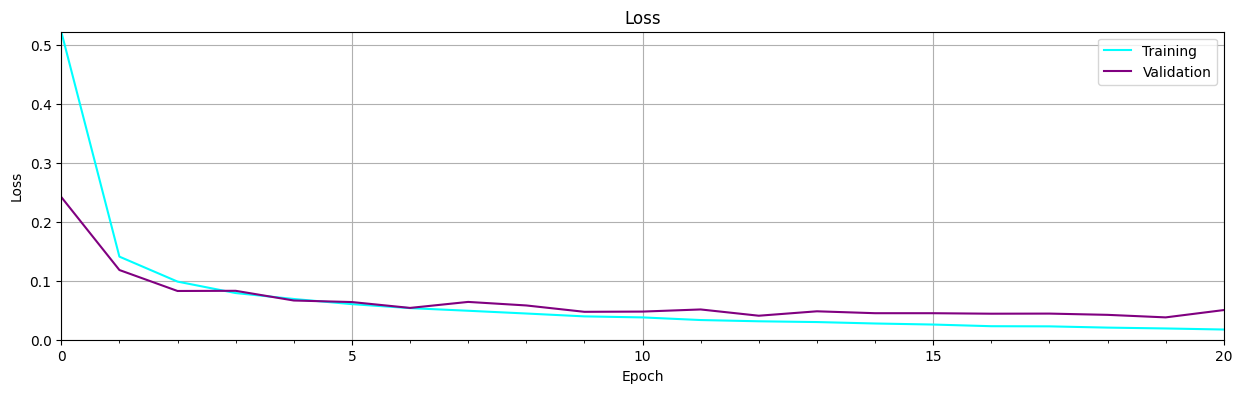

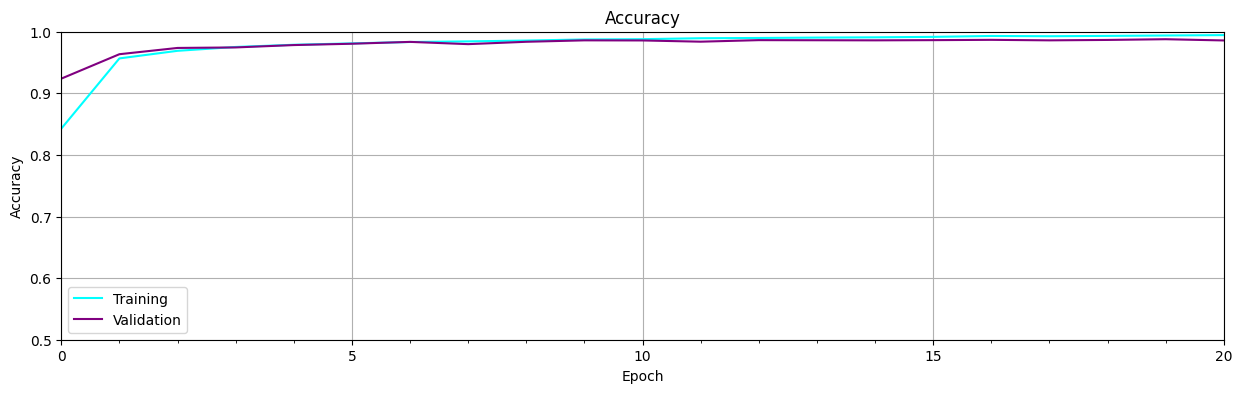

In [7]:
%run -i training.ipynb

In [12]:
test_set = (X_test, y_test)
test_results = evaluate_model(model, *test_set)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9859 - loss: 0.0507


In [13]:
print(test_results)

[0.050652164965867996, 0.9858999848365784]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


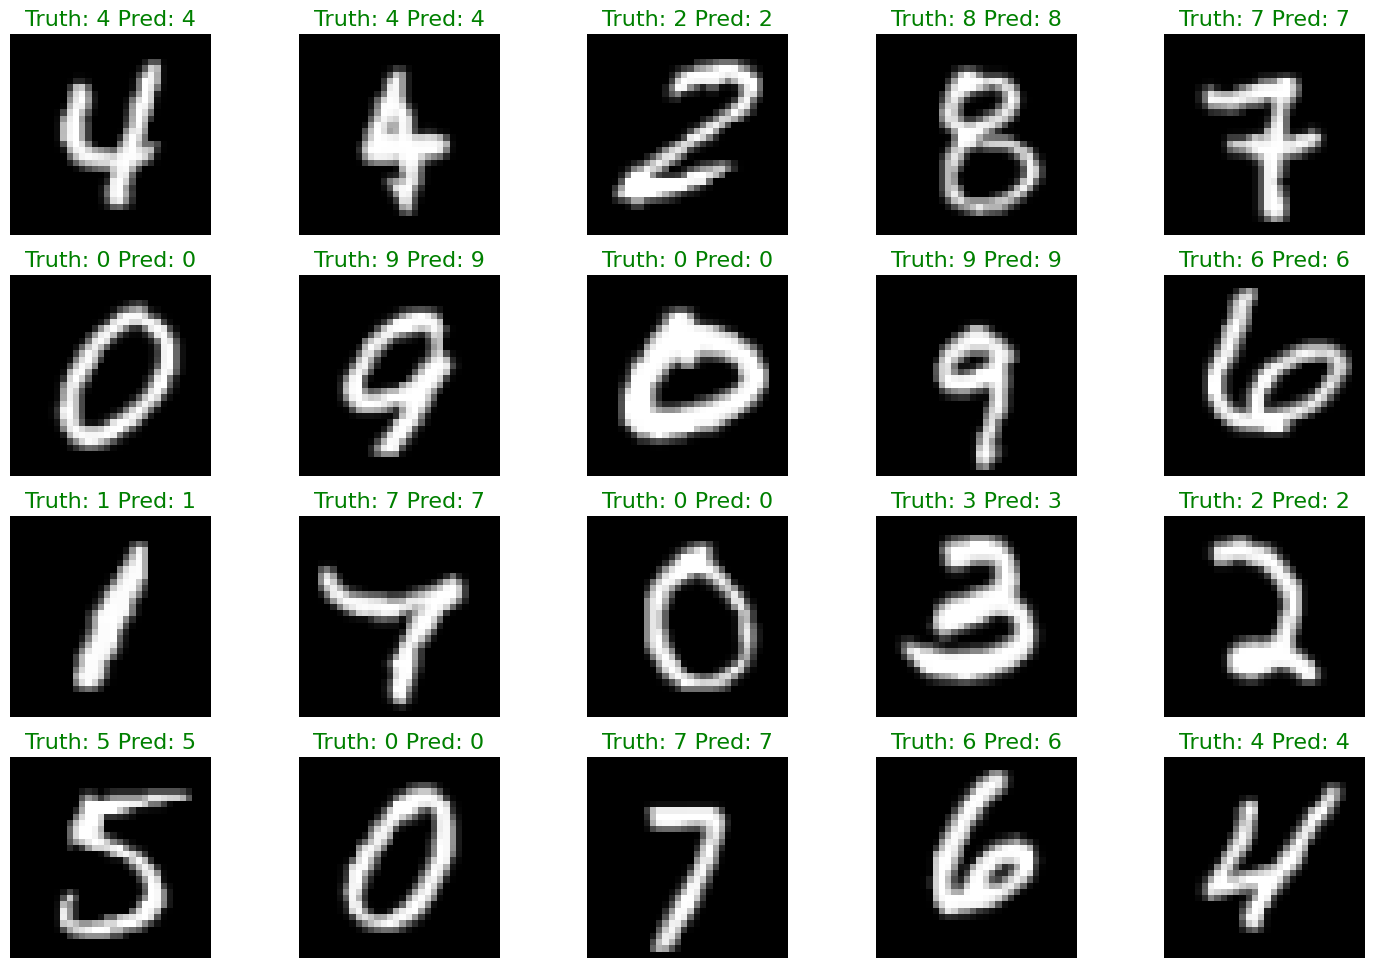

20


In [20]:
visualise_predictions(model, 30, *test_set)